#### I'm going to try out garch/arima models on this temperatures dataset. In this notebook, I'll compare the performances of this model to those implemented previously.

In [251]:
import pandas as pd
from sklearn.gaussian_process import GaussianProcessRegressor
import matplotlib.pyplot as plt
import numpy as np

In [252]:
train_df = pd.read_csv("DailyDelhiClimateTrain.csv")
test_df = pd.read_csv("DailyDelhiClimateTest.csv")

In [253]:
train_df.head()

,date,meantemp,humidity,wind_speed,meanpressure
0,2013-01-01,10.000000,84.500000,0.000000,1015.666667
1,2013-01-02,7.400000,92.000000,2.980000,1017.800000
2,2013-01-03,7.166667,87.000000,4.633333,1018.666667
3,2013-01-04,8.666667,71.333333,1.233333,1017.166667
4,2013-01-05,6.000000,86.833333,3.700000,1016.500000


### I'm going to try and predict the temperature. My metric will be the RMSE

### Preprocessing

In [254]:
train_df.isna().sum()

date            0
meantemp        0
humidity        0
wind_speed      0
meanpressure    0
dtype: int64

In [255]:
test_df.isna().sum()

date            0
meantemp        0
humidity        0
wind_speed      0
meanpressure    0
dtype: int64

### The dataset contains no missing values

In [256]:
train_df.describe()

,meantemp,humidity,wind_speed,meanpressure
count,1462.000000,1462.000000,1462.000000,1462.000000
mean,25.495521,60.771702,6.802209,1011.104548
std,7.348103,16.769652,4.561602,180.231668
min,6.000000,13.428571,0.000000,-3.041667
25%,18.857143,50.375000,3.475000,1001.580357
50%,27.714286,62.625000,6.221667,1008.563492
75%,31.305804,72.218750,9.238235,1014.944901
max,38.714286,100.000000,42.220000,7679.333333


Several variables contain outliers, but the most problematic ones appear in `meanpressure`.
The mean is around 1011, while the maximum reaches 7679, whereas the 75% quantile is only 1014.
This indicates the presence of extreme abnormal values.
 
To handle them, I clip the pressure values using empirical quantiles.
After plotting the distribution restricted to the interval between the $\alpha$ and $1-\alpha$ quantiles for several values of $\alpha$,
I observed that taking $\alpha = 0.01$ retains almost all of the meaningful mass of the distribution.

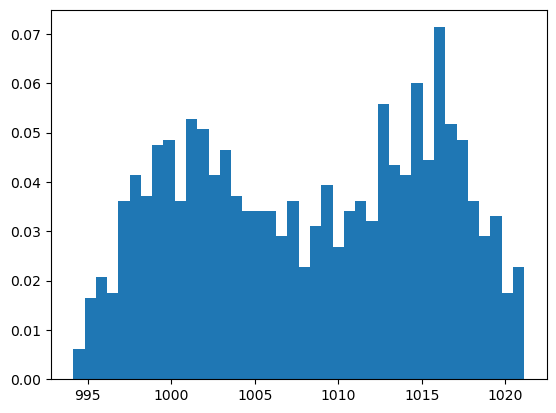

In [257]:
pressure = np.array(train_df["meanpressure"])
sorted_pressure = np.sort(pressure)
n = len(pressure)
plt.hist(sorted_pressure[int(0.01*n):int(0.99*n)], bins=40, density=True)
plt.show()


np.mean(pressure)

pressure_inf = sorted_pressure[int(0.01*n)]
pressure_sup = sorted_pressure[int(0.99*n)]

train_df["meanpressure_clipped"] = train_df["meanpressure"].clip(lower=pressure_inf, upper=pressure_sup)
test_df["meanpressure_clipped"] = test_df["meanpressure"].clip(lower=pressure_inf, upper=pressure_sup)


 ### Plotting the temperature series to get an initial sense of its temporal structure

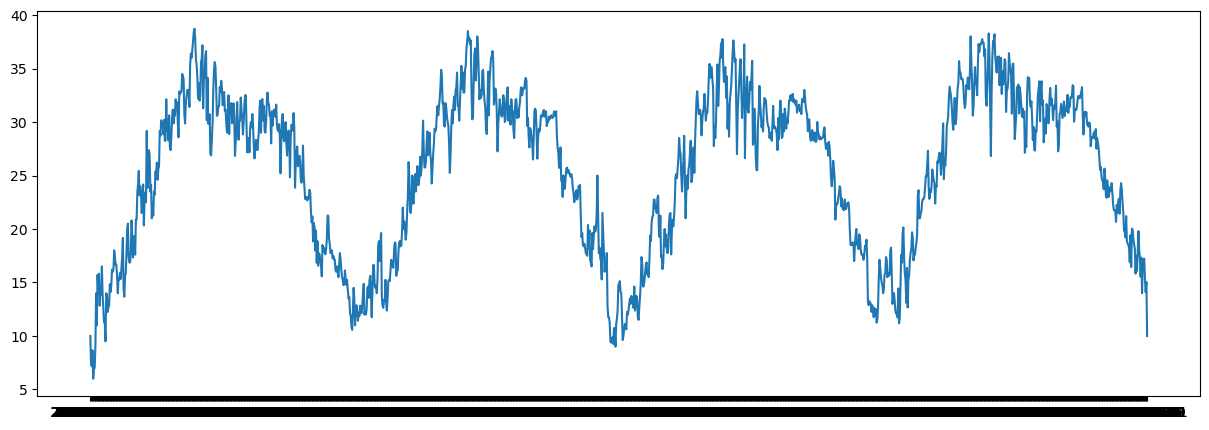

In [258]:
plt.figure(figsize=(15,5))
plt.plot(train_df["date"], train_df["meantemp"])
plt.show()


 As expected, the temperature exhibits a clear cyclical pattern.
 Capturing this periodic structure will be essential for accurate prediction.


 Next, I examine the distributions of the input variables.

C:\Users\tiots\AppData\Local\Temp\ipykernel_19424\3336102658.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[1,0].legend()


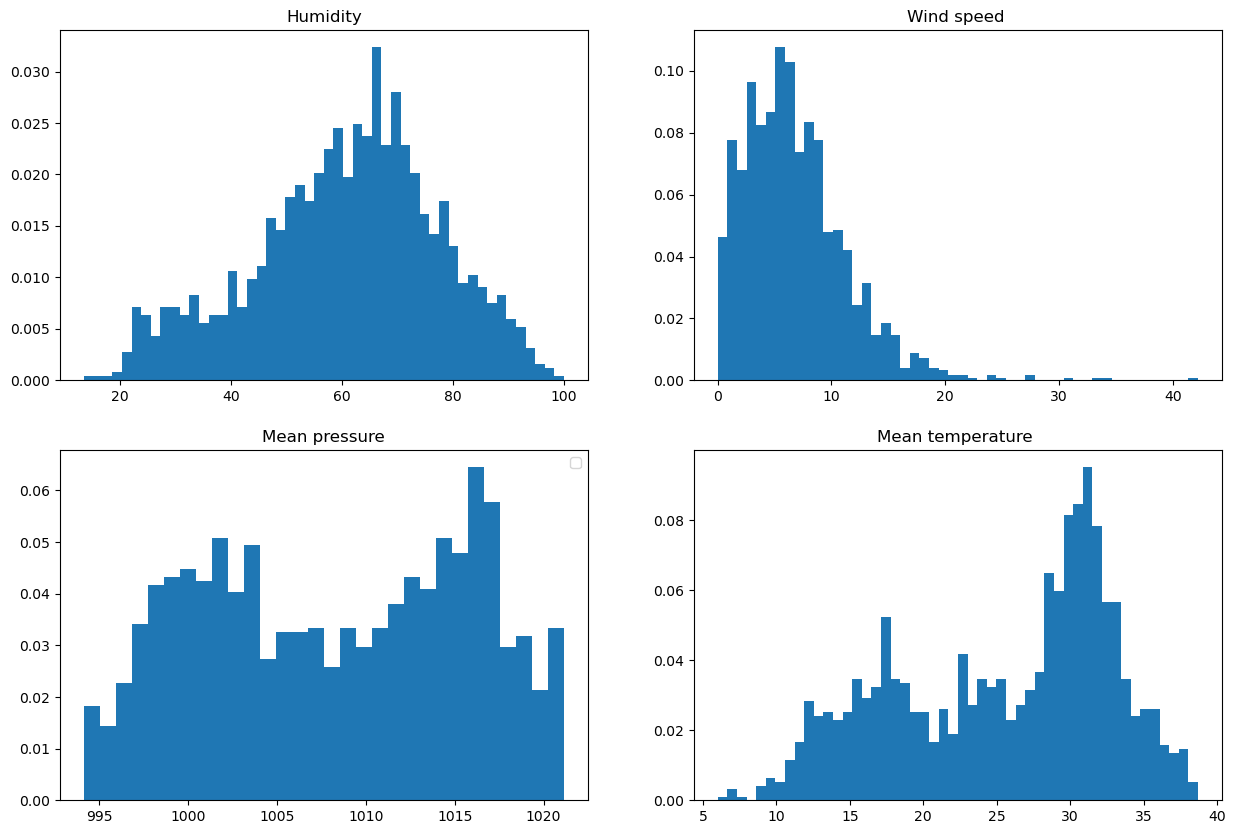

In [259]:
### Exploring other features
fig, ax = plt.subplots(figsize=(15,10), nrows=2, ncols=2)
ax[0,0].hist(train_df["humidity"], bins=50, density=True)
ax[0,0].set_title("Humidity")


ax[0,1].hist(train_df["wind_speed"], bins=50,density=True)
ax[0,1].set_title("Wind speed ")

ax[1,0].hist(train_df["meanpressure_clipped"], bins=30,density=True)
ax[1,0].set_title("Mean pressure")
ax[1,0].legend()

ax[1,1].hist(train_df["meantemp"], bins=50,density=True)
ax[1,1].set_title("Mean temperature ")
plt.show()

In [260]:
### To get things going, I convert the date into a number
train_df["date"] = pd.to_datetime(train_df["date"])
origine = train_df["date"].min()
train_df["date_num"] = train_df["date"] - origine
train_df["date_num"] = train_df["date_num"].dt.days

train_df = train_df.drop(columns=["date"])

### To get things going, I convert the date into a number
test_df["date"] = pd.to_datetime(test_df["date"])
test_df["date_num"] = test_df["date"] - origine
test_df["date_num"] = test_df["date_num"].dt.days

test_df = test_df.drop(columns=["date"])

In [261]:
train_df.head()

,meantemp,humidity,wind_speed,meanpressure,meanpressure_clipped,date_num
0,10.000000,84.500000,0.000000,1015.666667,1015.666667,0
1,7.400000,92.000000,2.980000,1017.800000,1017.800000,1
2,7.166667,87.000000,4.633333,1018.666667,1018.666667,2
3,8.666667,71.333333,1.233333,1017.166667,1017.166667,3
4,6.000000,86.833333,3.700000,1016.500000,1016.500000,4



 Scaling the variables before training

In [262]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
columns = ["humidity", "meanpressure_clipped", "wind_speed", "date_num"]
X_train, y_train = np.array(train_df[columns]), np.array(train_df["meantemp"])
X_train_s = scaler.fit_transform(X_train)
X_train_s[:,-1] = X_train[:,-1]

X_test, y_test = np.array(test_df[columns]), np.array(test_df["meantemp"])
X_test_s = scaler.transform(X_test)
X_test_s[:,-1] = X_test[:,-1]


In [263]:
def add_sin(X,period=365):
    t = X[:,-1].reshape(-1,1)

    X_aug = np.hstack([
        np.sin(2*np.pi*t/period),
        np.cos(2*np.pi*t/period),
        X
    ])
    
    return X_aug

# X_test_s = add_sin(X_test_s)
# X_train_s = add_sin(X_train_s)


 Before training the models, I examine the correlations between variables to get a rough sense of how much information may be extracted from them.

<Axes: >

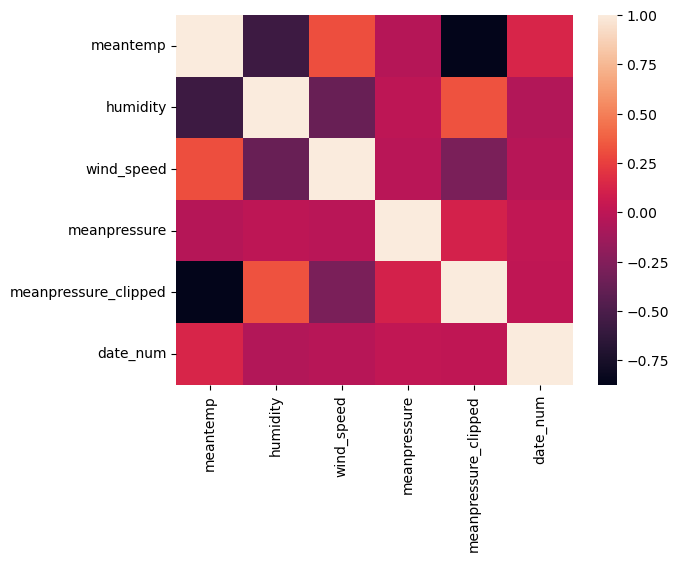

In [264]:
import seaborn as sns

correlation = train_df.corr()
sns.heatmap(correlation)


 This highlights the benefit of preprocessing `meanpressure`.
 The raw pressure variable has almost no correlation with `meantemp`,
 whereas the clipped version shows a noticeably stronger correlation in absolute value.
 Another important observation is that several features are correlated with one another.

<Axes: >

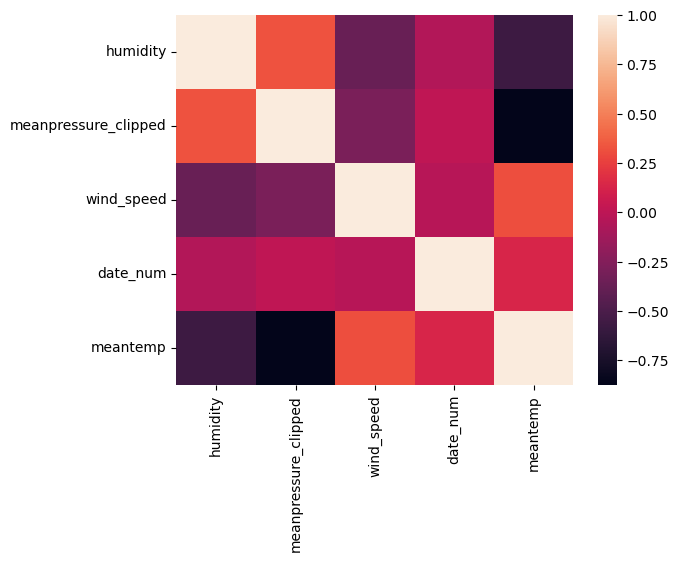

In [265]:
sns.heatmap(train_df[columns+["meantemp"]].corr())


 Note that these are only linear correlations.
 In particular, the weak correlation between temperature and date does not mean that no relationship exists,
 only that this relationship is not well described by a linear trend.

#### Next, I'm going to quantitatively look out for seasonality through an autocorrelation plot and look out for spikes.

In [266]:
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf
from scipy.signal import periodogram
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_pacf
import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA

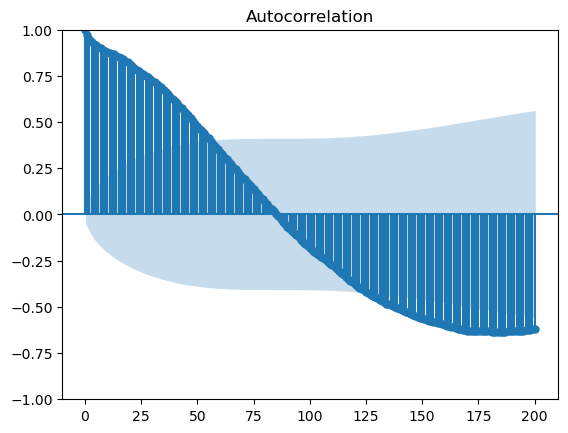

In [267]:
plot_acf(train_df["meantemp"], lags=200)
plt.show()

We clearly observe a sinusoidal pattern in the autocorrelation function, indicating that the temperature series is not stationary and exhibits a pronounced periodic structure. We therefore examine the periodogram in order to obtain a more precise estimate of the underlying period, which will be useful for deseasonalizing the data before fitting the models.


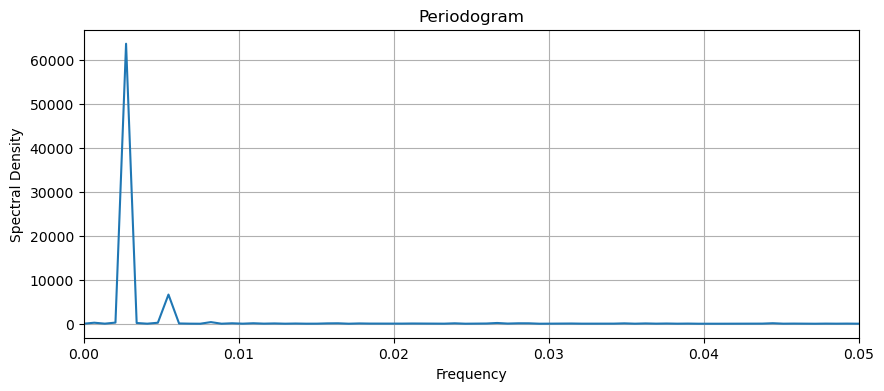

In [268]:


x = train_df["meantemp"].dropna().values   
fs = 1.0                                

freqs, Pxx = periodogram(x, fs=fs, detrend="linear", scaling="density")

plt.figure(figsize=(10, 4))
plt.plot(freqs, Pxx)
plt.xlabel("Frequency")
plt.ylabel("Spectral Density")
plt.title("Periodogram")
plt.xlim(0, 0.05)
plt.grid(True)
plt.show()

In [269]:
idx = Pxx.argmax()
print("Peak frequency:", freqs[idx])
print("Corresponding period:", 1/freqs[idx])

idx = Pxx.argsort()[-2]  # Get the index of the second largest peak
print("Second peak frequency:", freqs[idx])
print("Corresponding period:", 1/freqs[idx])

Peak frequency: 0.0027359781121751026
Corresponding period: 365.5
Second peak frequency: 0.005471956224350205
Corresponding period: 182.75


We clearly observe a strong spike at frequency $0.00274$, which corresponds to a period of approximately $365$ days. This is consistent with the annual seasonality of temperature, as expected: the succession of seasons follows a yearly cycle, and the temperature naturally reflects this pattern. A second spike appears at the frequency corresponding to a half-year period, which is also consistent with seasonal effects. One might perhaps have expected a stronger component at a quarter-year period, corresponding more directly to the four seasons familiar in Europe. We therefore deseasonalize the series by removing the annual and semi-annual components, which should be sufficient to capture the dominant seasonal structure and help make the series closer to stationarity.


In [270]:
X_train_s = add_sin(X_train_s, period=365)
X_test_s = add_sin(X_test_s, period=365)

X_train_s = add_sin(X_train_s, period=365/2)
X_test_s = add_sin(X_test_s, period=365/2)

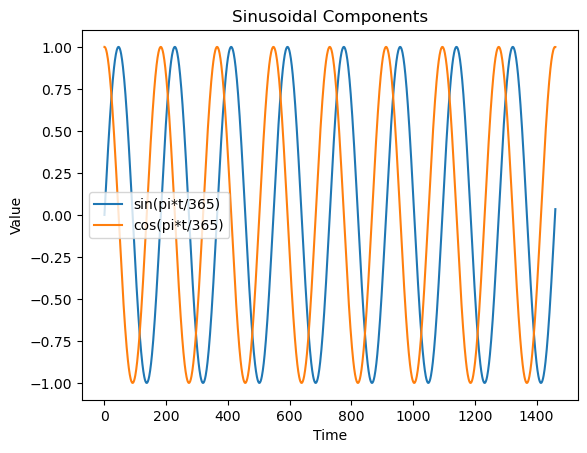

In [271]:
# plt.plot(range(len(X_train_s)), X_train_s[:,2], label="sin(2*pi*t/365)")
# plt.plot(range(len(X_train_s)), X_train_s[:,3], label="cos(2*pi*t/365)")

plt.plot(range(len(X_train_s)), X_train_s[:,0], label="sin(pi*t/365)")
plt.plot(range(len(X_train_s)), X_train_s[:,1], label="cos(pi*t/365)")

plt.xlabel("Time")
plt.ylabel("Value")
plt.title("Sinusoidal Components")
plt.legend()
plt.show()

In [272]:
### Deseasonalising the data

lin = np.linalg.lstsq(X_train_s[:,:4], y_train, rcond=None)[0]
y_train_deseasonalised = y_train - X_train_s[:,:4] @ lin

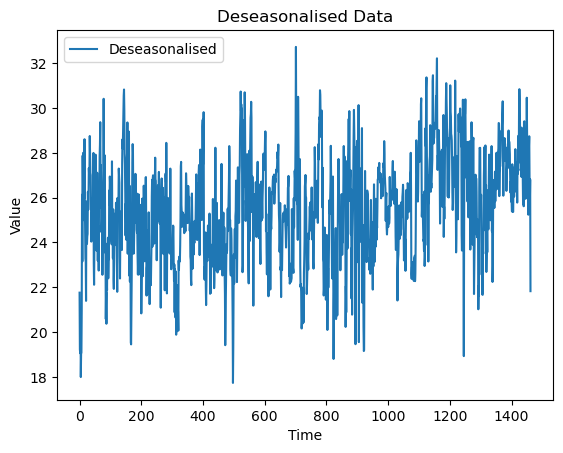

In [273]:
plt.plot(range(len(y_train)), y_train_deseasonalised, label="Deseasonalised")
plt.xlabel("Time")
plt.ylabel("Value")
plt.title("Deseasonalised Data")
plt.legend()
plt.show()

We still have some large amplitudes, but we notice that there is rather a trend in the deseasonalised data. We'll first try and remove the trend before further analysis

In [274]:
### Add 1 on the last column of X_train_s to do a linear regression with a bias
X_train_s = np.column_stack([X_train_s, np.ones(X_train_s.shape[0])])
# swap the last two columns to have the time as the last column, which is what we want for the linear regression
X_train_s[:, [-2, -1]] = X_train_s[:, [-1, -2]]
### Same for X_test_s
X_test_s = np.column_stack([X_test_s, np.ones(X_test_s.shape[0])])
X_test_s[:, [-1, -2]] = X_test_s[:, [-2, -1]] ## Swap the last two columns to have the time as the last column, which is what we want for the linear regression

lin_trend = np.linalg.lstsq(X_train_s[:, -2:], y_train_deseasonalised, rcond=None)[0]
y_train_detrended = y_train_deseasonalised - X_train_s[:, -2:] @ lin_trend

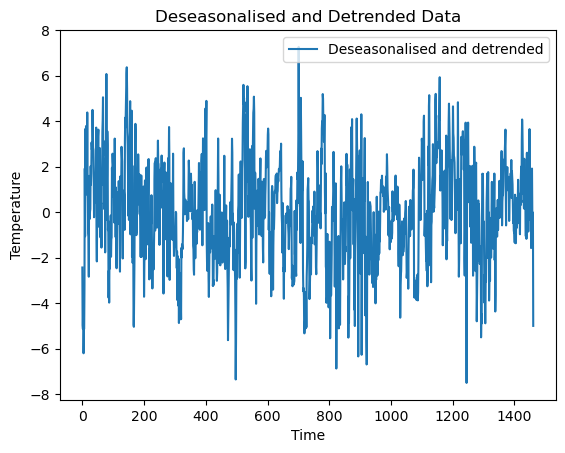

In [275]:
# print("Deseasonalised and detrended data:")
plt.plot(range(len(y_train)), y_train_detrended, label="Deseasonalised and detrended")
plt.xlabel("Time")
plt.ylabel("Temperature")
plt.title("Deseasonalised and Detrended Data")
plt.legend()
plt.show()

This signal seems to have a high amplitude, but rather seems stationary

In [276]:
lin_trend

array([2.41935599e+01, 1.80436823e-03])

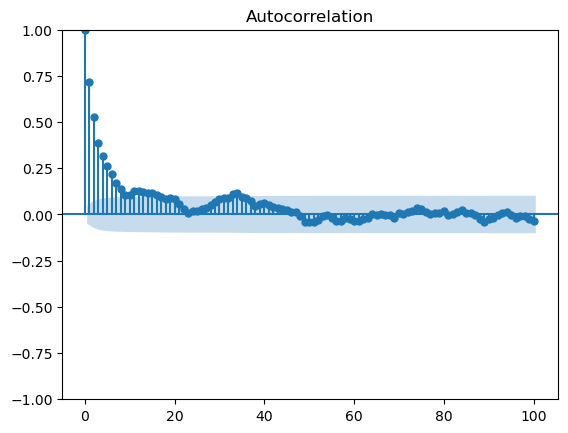

In [277]:
plot_acf(y_train_detrended, lags=100)
plt.show()

The ACF also suggests that autocorrelation becomes much weaker beyond lag 10. We now test whether the series is stationary using the Augmented Dickey--Fuller test, a standard statistical test for stationarity. The null hypothesis of the test is that the series contains a unit root, that is, that it is non-stationary. If the p-value falls below a chosen significance level, typically $0.05$, we reject the null hypothesis and conclude that the series may be considered stationary.


In [278]:
x = np.array(y_train_detrended)  # ou une Series pandas

result = adfuller(x)

print("ADF statistic :", result[0])
print("p-value       :", result[1])
print("used lags     :", result[2])
print("nobs          :", result[3])
print("critical vals :", result[4])

ADF statistic : -11.607265643996021
p-value       : 2.5631558169770994e-21
used lags     : 3
nobs          : 1458
critical vals : {'1%': -3.434843038681996, '5%': -2.8635243777871286, '10%': -2.56782646544019}


We obtain a p-value of $2.6 \times 10^{-21}$, which is far below the $0.05$ threshold. We therefore reject the null hypothesis and conclude that the series can reasonably be regarded as stationary. This suggests that fitting an ARIMA model to this data is appropriate, without major concerns about non-stationarity.


The ACF is useful for assessing the order of the moving-average component in the ARIMA model. Since it displays significant autocorrelation up to lag 10, it is reasonable to consider MA orders up to 10 and to fit the model for values of (q) in that range. At the same time, the partial autocorrelation function (PACF) should also be examined in order to guide the choice of the autoregressive order.


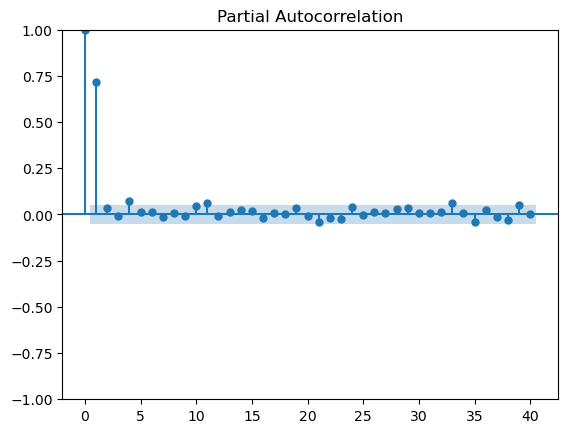

In [279]:
plot_pacf(y_train_detrended, lags=40, method="ywm")
plt.show()

We'll train the arima model for $p=1$, since the pacf is clearly insignificant after the lag 1.

In [280]:
p, d = 1,0 
q_values = list(range(11))

### Train many ARIMA models with different values of p and q, and select the one with the lowest AIC
best_aic = float("inf")
best_order = None
best_model = None

 # par exemple si tu as retenu d=1
for q in q_values:
    try:
        model = ARIMA(y_train_detrended, order=(p, d, q)).fit()
        if model.aic < best_aic:
            best_aic = model.aic
            best_order = (p, d, q)
            best_model = model
    except:
        print("Training failed for order (p,d,q) =", (p, d, q))

print("Best order:", best_order)
print("Best AIC:", best_aic)

Best order: (1, 0, 3)
Best AIC: 5422.412000090162


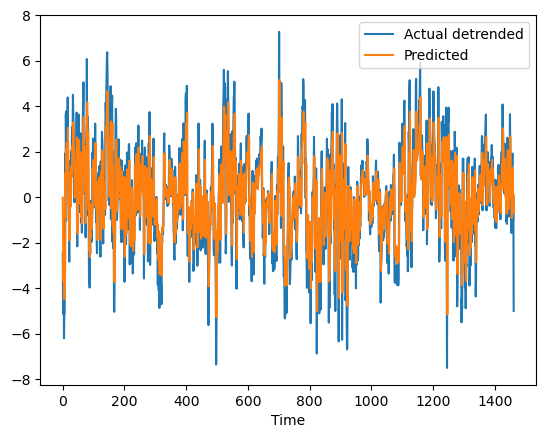

In [281]:
### In-sample predictions : 

y_hat = best_model.predict(start=0, end=len(y_train_detrended)-1)
plt.plot(range(len(y_train_detrended)), y_train_detrended, label="Actual detrended")
plt.plot(range(len(y_hat)), y_hat, label="Predicted")
plt.xlabel("Time")
plt.legend()
plt.show()

The in-sample fit is remarkably precise, which raises concerns about how the model may behave out of sample. We therefore turn to direct forecasting of the temperature series itself. As a first step, we forecast the entire test set using only the training data. We expect this approach to perform poorly, since the model is stationary and its autoregressive component is only of order 1. As a result, beyond the first few days, the forecasts are likely to collapse essentially to the estimated trend and seasonal components, which is unlikely to provide high accuracy.


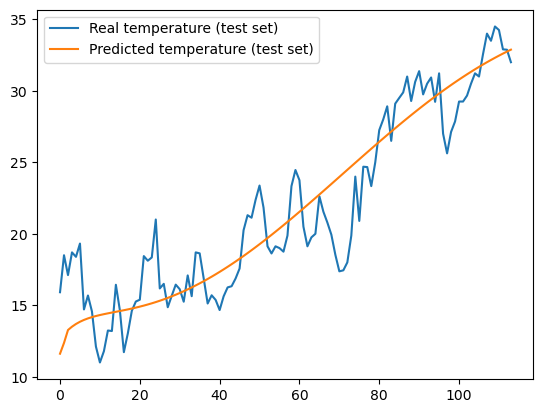

In [282]:
### prediction = prediction of detrended + seasonal + trend

y_trend_pred = best_model.forecast(steps=len(y_test))
y_pred = y_trend_pred + X_test_s[:,:4] @ lin + X_test_s[:,-2:] @ lin_trend

plt.plot(range(len(y_test)), y_test, label="Real temperature (test set)")
plt.plot(range(len(y_pred)), y_pred, label="Predicted temperature (test set)")

plt.legend()
plt.show()

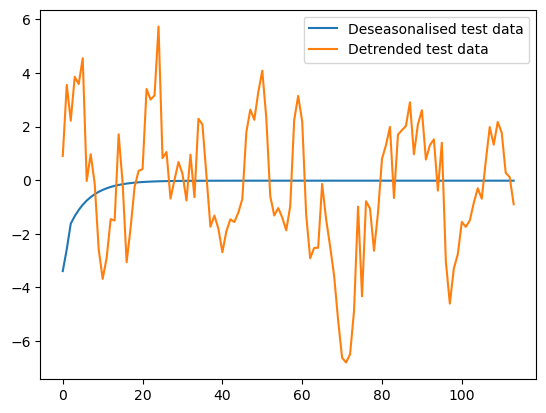

In [283]:
### Let's first see the predictions of the trend on the test set 

y_test_deseasonalised = y_test - X_test_s[:,:4] @ lin
y_test_detrended = y_test_deseasonalised - X_test_s[:,-2:] @ lin_trend

plt.plot(range(len(y_test)), y_trend_pred, label="Deseasonalised test data")
plt.plot(range(len(y_test)), y_test_detrended, label="Detrended test data")
plt.legend()
plt.show()


What we said previously is confirmed by the plot of the predictions of the trend. We rapidly converge to zero if we don't have the information of the previous value, which is not very accurate. 

We will use a one-step-ahead forecasting approach. At each time step, we predict the detrended temperature for the next period, then update the model with the actual detrended observation. This allows the model to refresh the residuals and all the information needed to forecast the following step. This is the standard way to use ARIMA models in forecasting, since they are autoregressive and rely on past observed values to produce accurate predictions.


In [284]:
###Predictions at one time step on a rolling basis : 

history = y_train_detrended.copy()
preds = []
stdev = []

cur_res = ARIMA(history, order=best_order).fit()

for t in range(len(y_test_detrended)):
    forecast = cur_res.get_forecast(steps=1)
    yhat = forecast.predicted_mean[0]
    preds.append(yhat)
    stdev.append(np.sqrt(forecast.se_mean[0]))

    # We add the true value to the history for the next prediction
    cur_res = cur_res.append(y_test_detrended[t:t+1], refit=False)

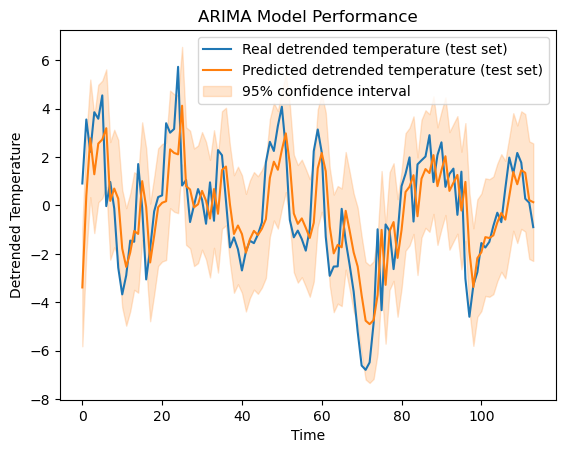

In [285]:
preds = np.array(preds)
stdev = np.array(stdev)

plt.plot(range(len(y_test_detrended)), y_test_detrended, label="Real detrended temperature (test set)")
plt.plot(range(len(y_test_detrended)), preds, label="Predicted detrended temperature (test set)")
plt.fill_between(range(len(y_test_detrended)), 
                 preds - 1.96*stdev,
                 preds + 1.96*stdev, 
                  color='tab:orange', alpha=0.2, label="95% confidence interval")
plt.xlabel("Time")
plt.ylabel("Detrended Temperature")
plt.title("ARIMA Model Performance")
plt.legend()
plt.show()

Our model seems quite performant at predicting the temperature. Though the predictions seem lagged compared to the real data. Let's then compare the predicted temperatures to the real ones, and compute the RMSE. But we may notice beforehand that all the real values lie in the $95\%$ confidence intervals.

In [286]:
rmse = np.sqrt(np.mean((preds - y_test_detrended)**2))
print(f"RMSE: {rmse:.4f}")

### Mean prediction error : 
mean_error = np.mean((preds - y_test_detrended)**2/stdev**2)
print(f"Mean Prediction Error: {mean_error:.4f}")

RMSE: 1.6546
Mean Prediction Error: 1.7788


We get a rmse of $1.65$ and a mean prediction error of $1.78$. The RMSE is already way better than the one obtained with the gaussian process regression, which was about $2.66$

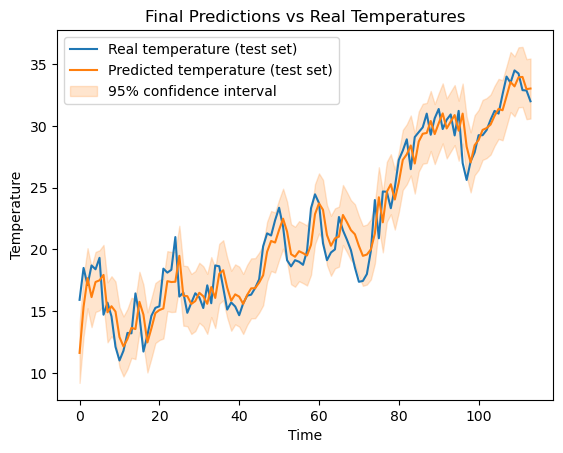

In [287]:
### Plot of the final predictions along with the real temperatures
y_pred = preds + X_test_s[:,:4] @ lin + X_test_s[:,-2:] @ lin_trend
plt.plot(range(len(y_test)), y_test, label="Real temperature (test set)")
plt.plot(range(len(y_pred)), y_pred, label="Predicted temperature (test set)")
plt.fill_between(range(len(y_pred)), 
                 y_pred - 1.96*stdev,
                    y_pred + 1.96*stdev,
                    color='tab:orange', alpha=0.2, label="95% confidence interval")
plt.xlabel("Time")
plt.ylabel("Temperature")
plt.title("Final Predictions vs Real Temperatures")
plt.legend()
plt.show()

## Conclusion

This provides a clear example of a setting in which a simple linear model can outperform more sophisticated approaches such as Gaussian process regression or XGBoost. In addition, the ARIMA model remains highly interpretable: the role of each component in the forecast can be understood directly. Its dependence on past observations is also explicitly specified, unlike Gaussian process regression, where temporal dependence was encoded more indirectly through kernels and correlation lengths involving previous time steps and other variables.

It is also worth noting that this model relies only on the temperature series. This suggests that performance could potentially be improved by incorporating additional variables, which was beyond the scope of the present analysis. This extension, together with the exploration of models such as LSTMs or transformers, may be considered in future work. Such models could in principle capture longer-range dependencies, although our ACF analysis did not reveal strong long-term temporal structure. As a result, more complex architectures may yield better results, but there is no guarantee. These questions are therefore left for future investigation.



### Appendix : Best model diagnostics

In [288]:
print(best_model.params)        # Estimated values
print(best_model.param_names)   # parameter names
print(best_model.bse)           # stdevs
print(best_model.pvalues)       # p-values
print(best_model.conf_int())    # confidence intervals
print(best_model.summary())  

[-0.0183614   0.8250084  -0.13144003 -0.05774357 -0.10002782  2.36867487]
['const', 'ar.L1', 'ma.L1', 'ma.L2', 'ma.L3', 'sigma2']
[0.16867268 0.03507195 0.04175234 0.03454894 0.03345762 0.06904566]
[9.13314992e-001 2.35530189e-122 1.64342453e-003 9.46514352e-002
 2.79263502e-003 6.40352232e-258]
[[-0.34895378  0.31223098]
 [ 0.75626865  0.89374815]
 [-0.21327311 -0.04960694]
 [-0.12545826  0.00997111]
 [-0.16560355 -0.03445208]
 [ 2.23334788  2.50400187]]
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 1462
Model:                 ARIMA(1, 0, 3)   Log Likelihood               -2705.206
Date:                Sun, 19 Apr 2026   AIC                           5422.412
Time:                        11:23:40   BIC                           5454.137
Sample:                             0   HQIC                          5434.246
                               - 1462                             

### Interpretation of some parameters :
- `ar.L1`: This is the coefficient for the autoregressive term of order 1. It indicates how much the current value of the series is influenced by its immediately preceding value. The value of $0.86$ suggests that there is a strong positive relationship between the current value and the previous value of the series, and that a high temperature on one day is likely to be followed by a high temperature on the next day.
- `sigma2`: This is the variance of the error term in the ARIMA model. A value of $2.36$ indicates the level of variability in the residuals (the differences between the observed and predicted values). A lower value would indicate that the model's predictions are closer to the actual values, while a higher value suggests more variability in the predictions. 